In [56]:
import pandas
import os

In [57]:
datasets_path = "data"
years = [2019,2020, 2021, 2022, 2023, 2024]

df_lieux = []

for year in years:
    df_lieux_year = pandas.read_csv(os.path.join(datasets_path, str(year), f"lieux-{year}.csv"), encoding="utf-8", sep = ";", dtype=str)
    df_lieux.append(df_lieux_year)

df_lieux = pandas.concat(df_lieux)
df_lieux

,Num_Acc,catr,voie,v1,v2,circ,nbv,vosp,prof,pr,pr1,plan,lartpc,larrout,surf,infra,situ,vma
0,201900000001,1,3,0,NaN,3,10,0,1,6,900,2,NaN,NaN,1,2,1,70
1,201900000002,1,1,0,NaN,1,2,0,4,3,845,2,NaN,NaN,1,0,1,70
2,201900000003,1,86,0,NaN,3,8,0,1,10,500,3,NaN,NaN,1,0,1,90
3,201900000004,1,4,0,NaN,3,5,0,1,2,299,1,NaN,NaN,1,0,1,90
4,201900000005,1,86,0,INT,1,3,0,1,41,0,3,NaN,NaN,1,2,1,90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70243,202400054398,3,NaN,-1,NaN,1,1,-1,1,-1,-1,1,NaN,-1,2,5,4,-1
70244,202400054399,3,RUE PIERRE GAUDIN,0,NaN,1,1,2,1,0,0,2,NaN,-1,1,0,1,30
70245,202400054400,2,12,0,NaN,1,2,0,2,31,1 000,1,NaN,10,1,0,1,110
70246,202400054401,3,JEAN JAURES (BOULEVARD) 63/215 - 70/208,0,NaN,2,3,0,1,0,0,1,NaN,"10,5",1,0,1,50


In [58]:
# First we are dropping features that we are not going to use
df_lieux.drop(columns = ['voie', 'v1', 'v2', 'pr', 'pr1', 'lartpc', 'larrout'], inplace = True)

In [59]:
df_lieux.columns

Index(['Num_Acc', 'catr', 'circ', 'nbv', 'vosp', 'prof', 'plan', 'surf',
       'infra', 'situ', 'vma'],
      dtype='str')

In [60]:
column_names_to_int = ['catr', 'circ', 'nbv', 'vosp', 'prof', 'plan', 'surf',
       'infra', 'situ', 'vma']

df_lieux[column_names_to_int] = df_lieux[column_names_to_int].apply(
    lambda col: pandas.to_numeric(
        col.astype(str).str.extract(r'(-?\d+)')[0],
        errors="coerce"
    )
)

In [61]:
df_lieux.replace(-1, pandas.NA, inplace=True)
df_lieux.isna().sum()

Num_Acc        0
catr           0
circ       21559
nbv        10666
vosp        9108
prof         299
plan         238
surf         310
infra       3971
situ         378
vma        11601
dtype: int64

In [62]:
# Removing rows with missing values
df_lieux = df_lieux.dropna()

# And converting to int
cols_small_int = ['Num_Acc', 'catr', 'circ', 'nbv', 'vosp', 'prof', 'plan', 'surf',
       'infra', 'situ', 'vma']
df_lieux[cols_small_int] = df_lieux[cols_small_int].astype("int64")

In [63]:
features = ['catr', 'circ', 'nbv', 'vosp', 'prof', 'plan', 'surf',
       'infra', 'situ', 'vma']

categorical_features_lieux = ['catr', 'circ', 'nbv', 'vosp', 'prof', 'plan', 'surf',
       'infra', 'situ', 'vma']

numerical_features_caract = []

In [64]:
# Let's correct outliers that contain vma column
df_lieux["vma"].value_counts()
valid_limits = [5,10,15,20,30,50,70,80,90,110,130]
df_lieux['vma'] = df_lieux['vma'].where(df_lieux['vma'].isin(valid_limits), None)
df_lieux['vma'].isna().sum()
df_lieux = df_lieux.dropna()

In [65]:
df_lieux_analyse = df_lieux.copy() 

mapping = {
1: "Autoroute",  
2: "Route nationale",  
3: "Route Départementale",  
4: "Voie Communales",  
5: "Hors réseau public",  
6: "Parc de stationnement ",  
7: "Routes de métropole urbaine",  
9: "Autre" }
df_lieux_analyse["catr"] = df_lieux_analyse["catr"].replace(mapping)

mapping = {
1: "A sens unique",
2: "Bidirectionnelle",
3: "A chaussées séparées",
4: "Avec voies d’affectation variable" }
df_lieux_analyse["circ"] = df_lieux_analyse["circ"].replace(mapping)

# vosp
mapping = {
1: "A sens unique",  
2: "Bidirectionnelle",  
3: "A chaussées séparées",  
4: "Avec voies d’affectation variable"}
df_lieux_analyse["circ"] = df_lieux_analyse["circ"].replace(mapping)

mapping = {
1: "Plat",  
2: "Pente",  
3: "Sommet de côte",  
4: "Bas de côte" }
df_lieux_analyse["prof"] = df_lieux_analyse["prof"].replace(mapping)

mapping = {
1: "Partie rectiligne",  
2: "En courbe à gauche",  
3: "En courbe à droite", 
4: "En « S »"}
df_lieux_analyse["plan"] = df_lieux_analyse["plan"].replace(mapping)

mapping = {
1: "Normale",   
2: "Mouillée",   
3: "Flaques",   
4: "Inondée",   
5: "Enneigée",   
6: "Boue",  
7: "Verglacée",   
8: "Corps gras – huile",   
9: "Autre"}
df_lieux_analyse["surf"] = df_lieux_analyse["surf"].replace(mapping)

mapping = {
0: "Aucun",   
1: "Souterrain - tunnel",  
2: "Pont - autopont",  
3: "Bretelle d’échangeur ou de raccordement",  
4: "Voie ferrée",  
5: "Carrefour aménagé",  
6: "Zone piétonne",  
7: "Zone de péage",  
8: "Chantier",  
9: "Autres" }
df_lieux_analyse["infra"] = df_lieux_analyse["infra"].replace(mapping)

mapping = {
0: "Aucun",
1: "Sur chaussée",  
2: "Sur bande d’arrêt d’urgence",  
3: "Sur accotement",  
4: "Sur trottoir",  
5: "Sur piste cyclable",  
6: "Sur autre voie spéciale",  
8: "Autres"}
df_lieux_analyse["situ"] = df_lieux_analyse["situ"].replace(mapping)

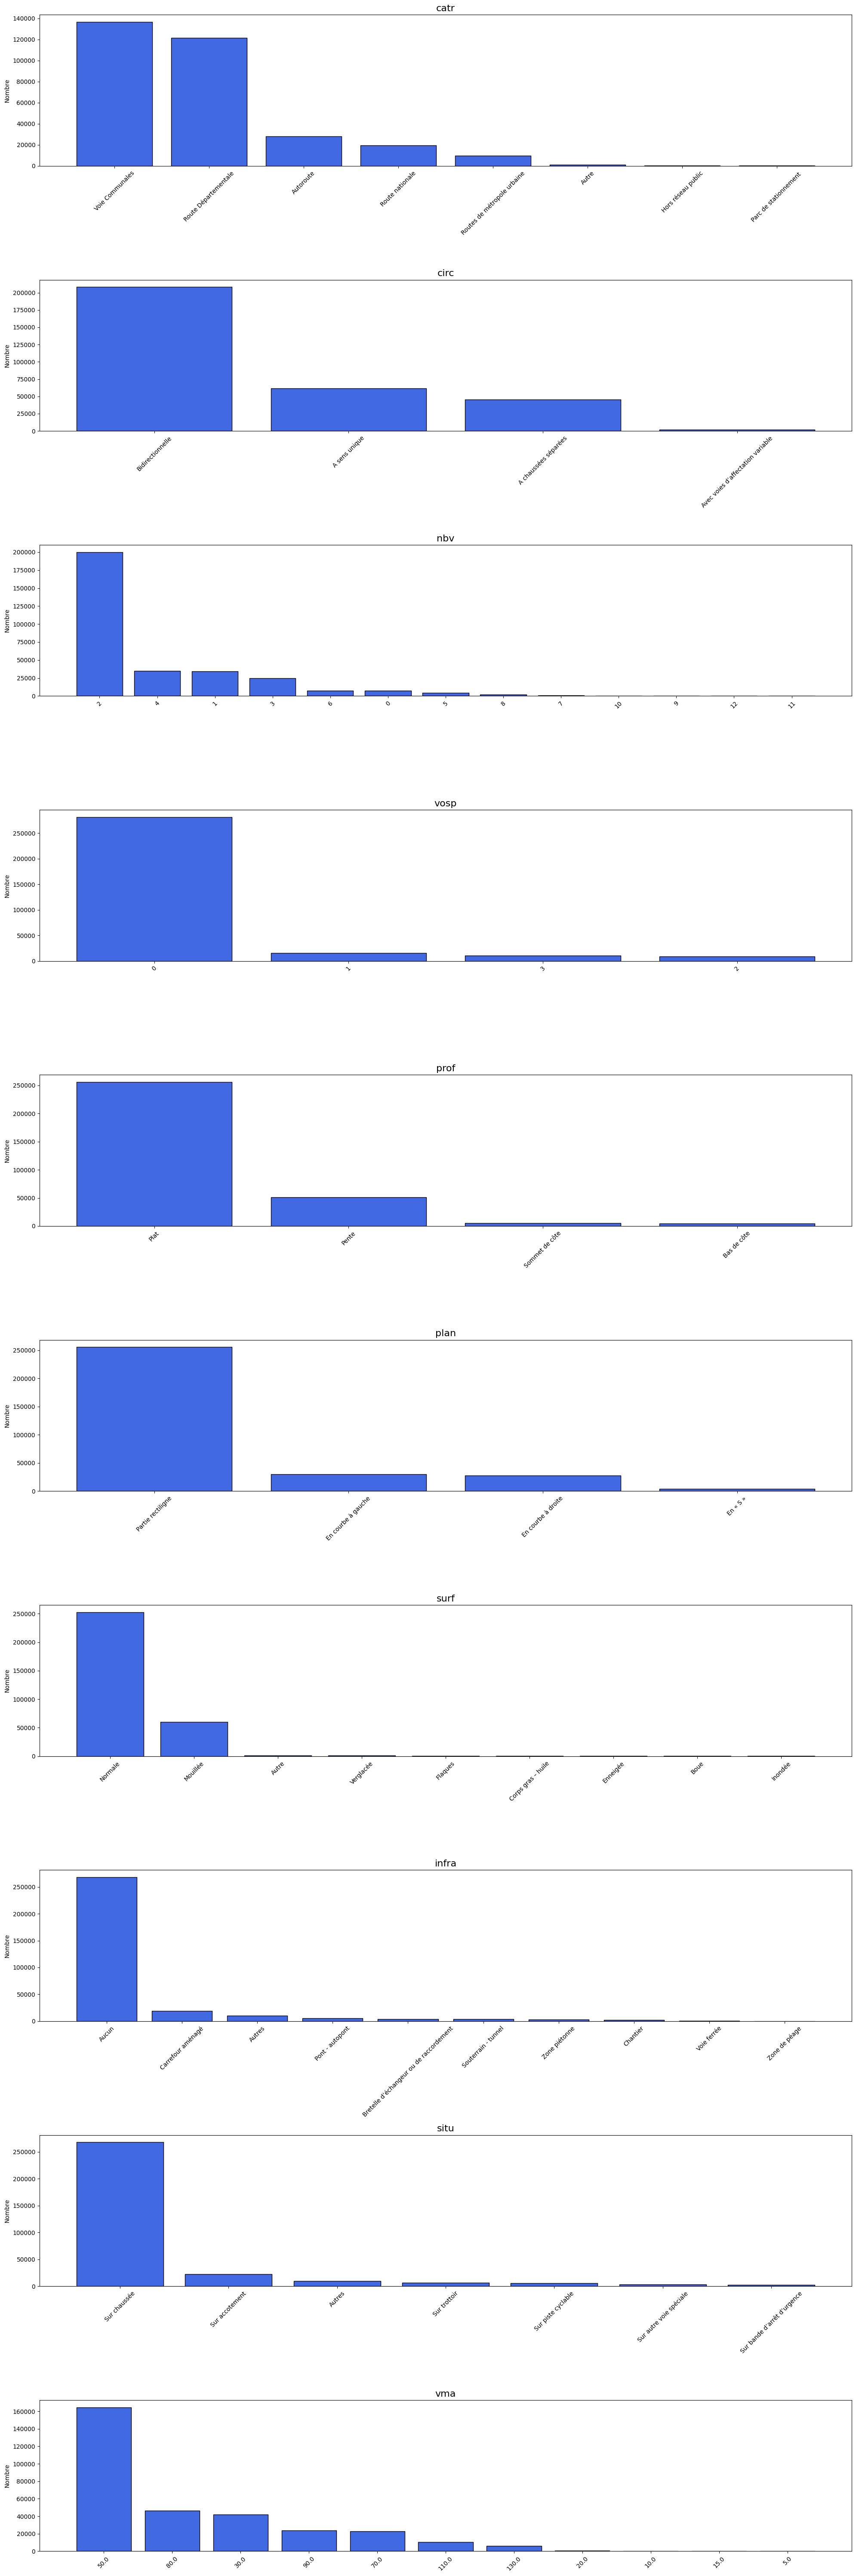

In [66]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(len(categorical_features_lieux), 1, figsize=(20, 6*len(categorical_features_lieux)))

for i, feature in enumerate(categorical_features_lieux):
    values = df_lieux_analyse[feature]
    counts = values.value_counts()
    
    ax[i].bar(counts.index.astype(str), counts.values, color="royalblue", edgecolor="black")
    ax[i].set_title(feature, fontsize=16)
    ax[i].tick_params(axis='x', rotation=45)
    ax[i].set_ylabel("Nombre")

plt.tight_layout()

In [67]:
# We need to load usagers, because it conatains our target column
df_usagers = pandas.read_csv("df_usagers_clean.csv")

In [68]:
df_lieux_with_target = df_lieux.merge(
    df_usagers[['Num_Acc', 'grav_bin']],
    on='Num_Acc',
    how='left'
)
target = "grav_bin"

In [69]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X = pandas.get_dummies(df_lieux_with_target[features], drop_first=True) # treat the as categories
y = df_lieux_with_target[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

importances = pandas.Series(model.feature_importances_, index=X.columns)
print(importances.sort_values(ascending=False))

vma      0.200152
situ     0.174192
catr     0.129825
nbv      0.122303
circ     0.083127
infra    0.081679
plan     0.062791
prof     0.053756
surf     0.053517
vosp     0.038659
dtype: float64


In [70]:
from sklearn.feature_selection import mutual_info_classif

X = pandas.get_dummies(df_lieux_with_target[features], drop_first=True)
y = df_lieux_with_target[target]

mi = mutual_info_classif(X, y)

pandas.Series(mi, index=X.columns).sort_values(ascending=False)

situ     0.081671
surf     0.073219
plan     0.069846
vma      0.062905
circ     0.059061
prof     0.055810
catr     0.054986
nbv      0.049159
vosp     0.003044
infra    0.002922
dtype: float64

In [71]:
# We can see that we can drop "vosp" feauture as it is ranked at the end in both evaluations.
features_to_remove = ["vosp"]
df_lieux.drop(columns=features_to_remove, inplace=True)
df_lieux_with_target.drop(columns=features_to_remove, inplace=True)
features = list(set(features) - set(features_to_remove))

In [72]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

X = pandas.get_dummies(df_lieux_with_target[features], drop_first=True)
y = df_lieux_with_target[target] 

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    # "Random Forest": RandomForestClassifier(n_estimators=100),
    "Gradient Boosting": GradientBoostingClassifier()
}

for name, model in models.items():
    model.fit(X_train, y_train)

In [73]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

for name, model in models.items():

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]

    print("\n", name)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))


 Logistic Regression
Accuracy: 0.8190768113614624
              precision    recall  f1-score   support

           0       0.82      1.00      0.90    117387
           1       0.46      0.02      0.04     25834

    accuracy                           0.82    143221
   macro avg       0.64      0.51      0.47    143221
weighted avg       0.76      0.82      0.74    143221


 Decision Tree
Accuracy: 0.8212831917107128
              precision    recall  f1-score   support

           0       0.84      0.97      0.90    117387
           1       0.52      0.13      0.21     25834

    accuracy                           0.82    143221
   macro avg       0.68      0.55      0.55    143221
weighted avg       0.78      0.82      0.77    143221


 Gradient Boosting
Accuracy: 0.8248441220212119
              precision    recall  f1-score   support

           0       0.83      0.98      0.90    117387
           1       0.57      0.12      0.19     25834

    accuracy                         

AUC of Logistic Regression: 0.664
AUC of Decision Tree: 0.699
AUC of Gradient Boosting: 0.717


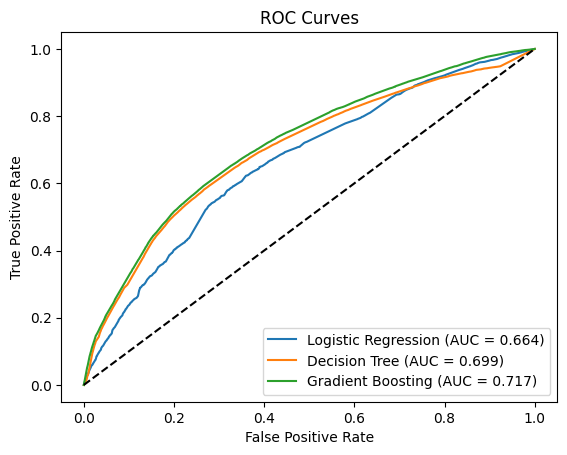

In [74]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure()

lst_auc = []

for name, model in models.items():

    y_proba = model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_score = auc(fpr, tpr)

    lst_auc.append((name, auc_score))

    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")

    print(f"AUC of {name}: {auc_score:.3f}")

plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

In [75]:
# Finally we are going to save the dataset cleaned
df_lieux.to_csv("df_lieux_clean.csv", index=False)

In [76]:
df_lieux = pandas.read_csv("df_lieux_clean.csv")

In [77]:
print("All columns:", df_lieux.columns)
print("Features:", features)

All columns: Index(['Num_Acc', 'catr', 'circ', 'nbv', 'prof', 'plan', 'surf', 'infra',
       'situ', 'vma'],
      dtype='str')
Features: ['circ', 'catr', 'prof', 'vma', 'situ', 'infra', 'surf', 'nbv', 'plan']
